# Explore raw daily data
**OHLCV daily · Binance Futures perpetuals · 2019–2026**

1. Prix normalisé multi-assets (base 100)
2. Rendements daily et leur distribution
3. Drawdown depuis le plus haut
4. Statistiques résumées

In [1]:
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams.update({'figure.dpi': 130, 'font.size': 9})

RAW      = pathlib.Path.home() / 'Downloads' / 'dfi-quant' / 'data' / 'raw'
EXCHANGE = 'binance-futures'
SYMBOLS  = ['BTCUSDT', 'ETHUSDT', 'SOLUSDT', 'LTCUSDT', 'BNBUSDT']
COLORS   = {
    'BTCUSDT': '#F7931A',
    'ETHUSDT': '#627EEA',
    'SOLUSDT': '#9945FF',
    'LTCUSDT': '#BFBBBB',
    'BNBUSDT': '#F3BA2F',
}

def load_daily(symbol: str) -> pd.DataFrame:
    base = (RAW / f'exchange={EXCHANGE}' / 'data_type=ohlcv_1d' / f'symbol={symbol}')
    frames = [pd.read_parquet(f) for f in sorted(base.glob('**/*.parquet'))
              if '_tmp' not in str(f)]
    if not frames:
        return pd.DataFrame()
    df = pd.concat(frames, ignore_index=True).sort_values('ts_open')
    df['date'] = pd.to_datetime(df['ts_open'], unit='us', utc=True).dt.normalize()
    df['ret']  = np.log(df['close'] / df['close'].shift(1))
    return df.set_index('date')

data = {s: load_daily(s) for s in SYMBOLS}
for s, df in data.items():
    if df.empty:
        print(f'{s}: no data')
    else:
        print(f'{s}: {len(df)} jours  |  {df.index.min().date()} -> {df.index.max().date()}')

BTCUSDT: 2322 jours  |  2020-01-01 -> 2026-05-10
ETHUSDT: 2322 jours  |  2020-01-01 -> 2026-05-10
SOLUSDT: 2065 jours  |  2020-09-14 -> 2026-05-10
LTCUSDT: 2314 jours  |  2020-01-09 -> 2026-05-10
BNBUSDT: 2282 jours  |  2020-02-10 -> 2026-05-10


## 1 · Prix normalisé sur 3 ans (base 100) + Volume BTC

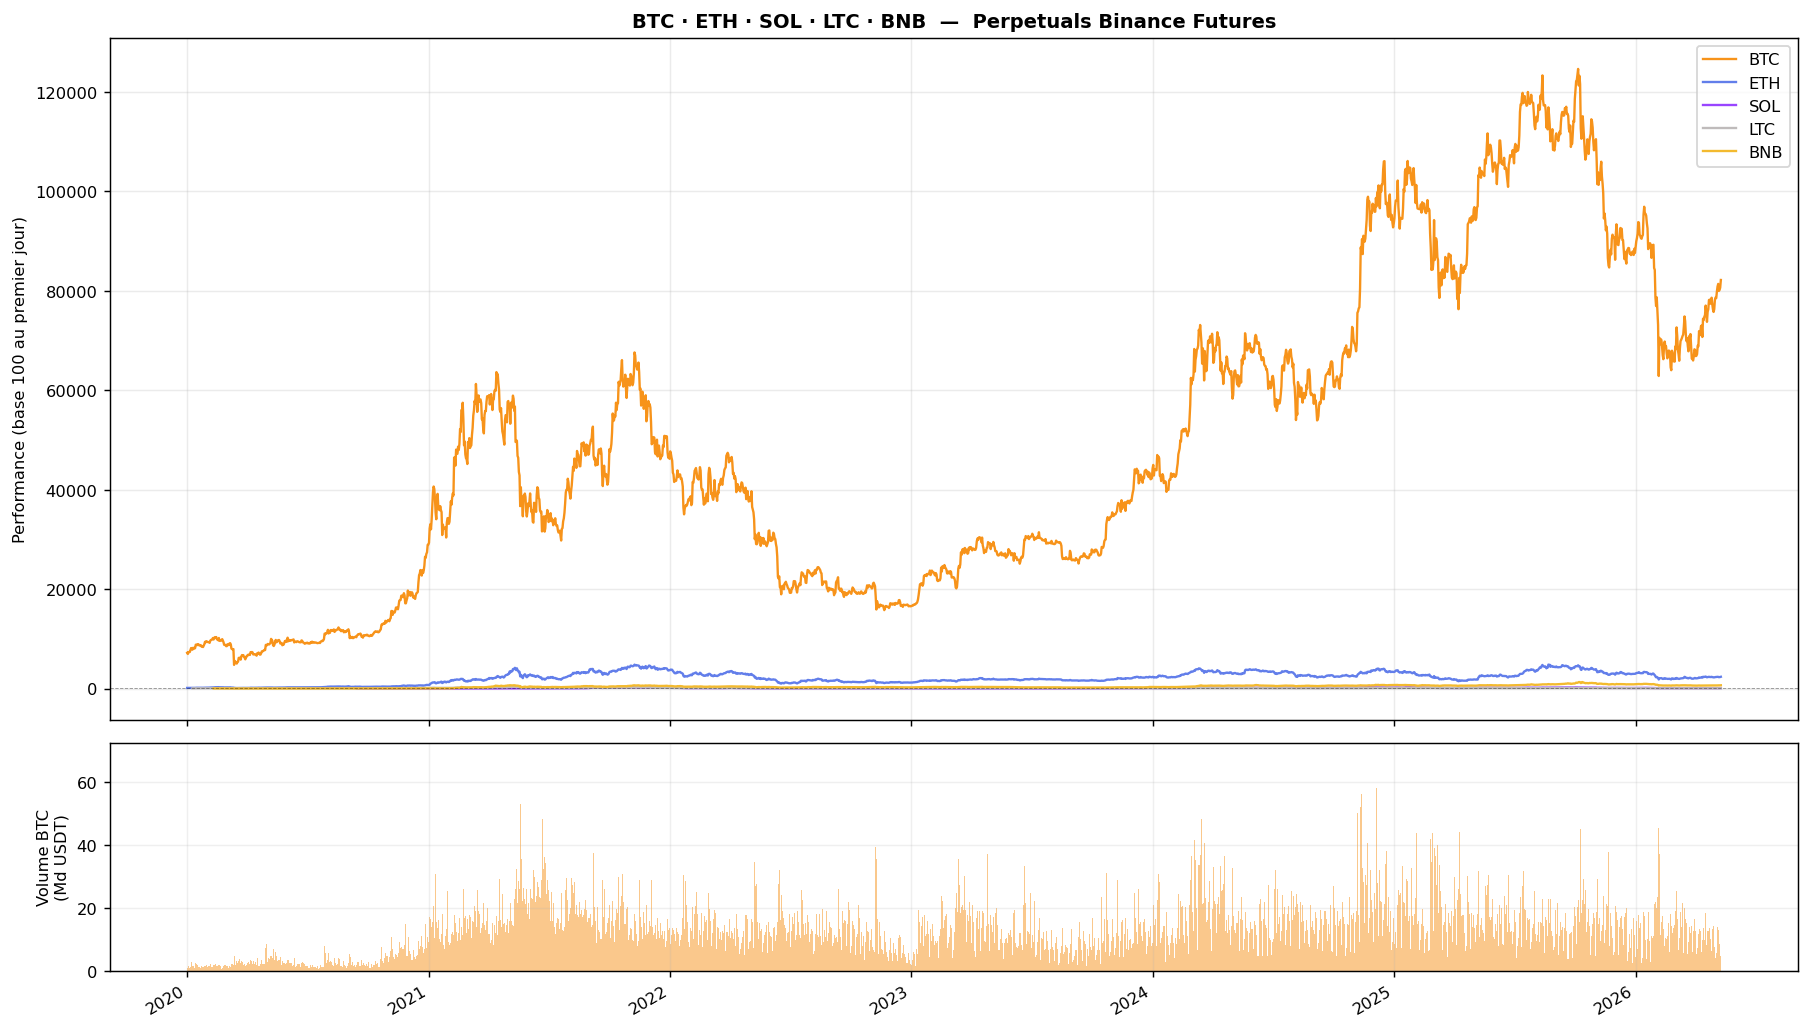

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1]})

ax = axes[0]
for sym, df in data.items():
    if df.empty:
        continue
    perf = df['close'] 
    ax.plot(df.index, perf, label=sym.replace('USDT', ''),
            color=COLORS[sym], lw=1.3)
ax.axhline(100, color='k', lw=0.5, ls='--', alpha=0.4)
ax.set_ylabel('Performance (base 100 au premier jour)')
ax.set_title('BTC · ETH · SOL · LTC · BNB  —  Perpetuals Binance Futures',
             fontweight='bold')
ax.legend()
ax.grid(alpha=0.25)

ax = axes[1]
btc = data['BTCUSDT']
ax.bar(btc.index, btc['quote_vol'] / 1e9, width=1,
       color='#F7931A', alpha=0.5)
ax.set_ylabel('Volume BTC\n(Md USDT)')
ax.grid(alpha=0.2)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
plt.xticks(rotation=30, ha='right')

plt.tight_layout()
plt.show()

## 2 · Rendements daily et distribution

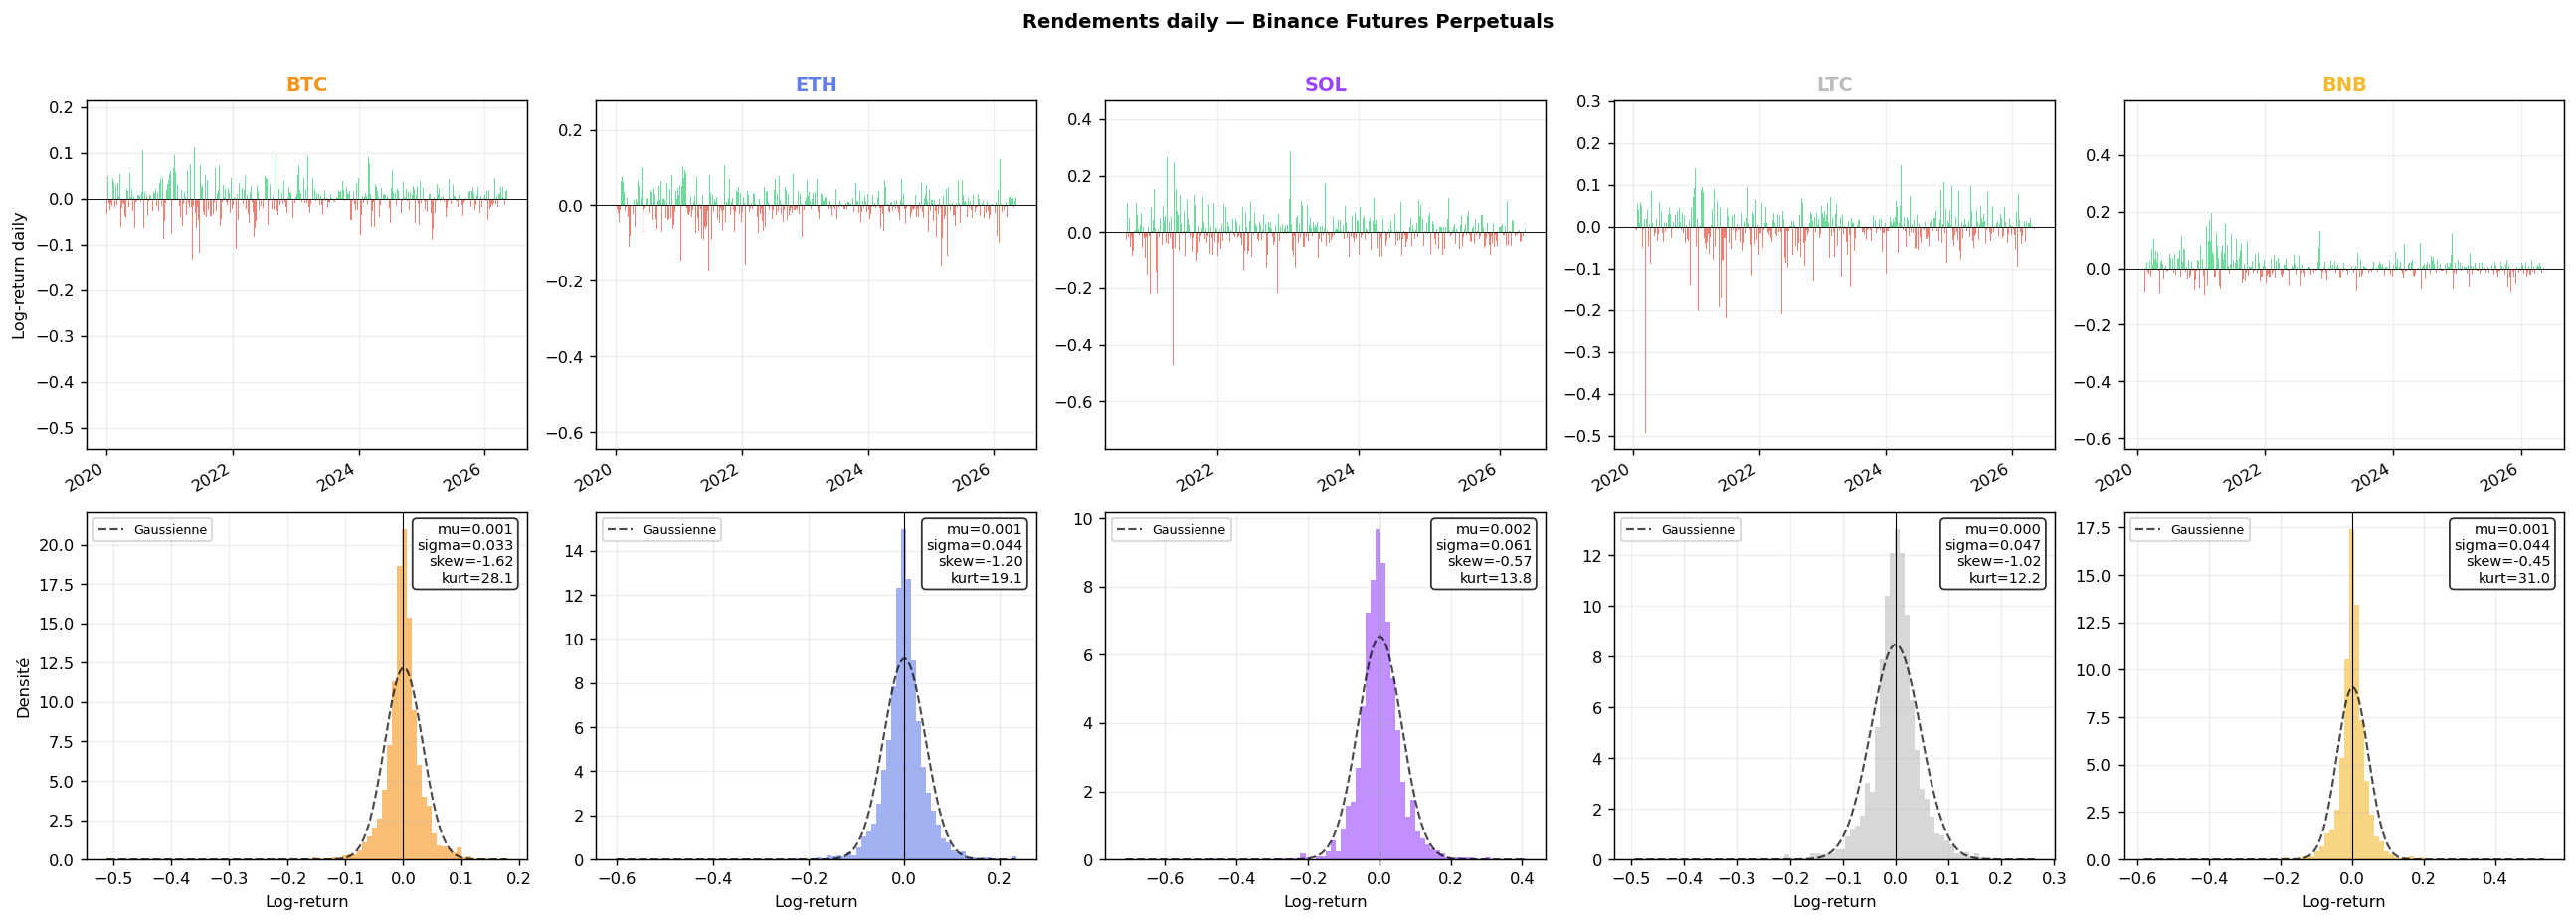

In [3]:
active = [(s, df) for s, df in data.items() if not df.empty]
n = len(active)
fig, axes = plt.subplots(2, n, figsize=(4 * n, 7))

for col, (sym, df) in enumerate(active):
    ret = df['ret'].dropna()
    c   = COLORS[sym]

    ax = axes[0, col]
    ax.bar(ret.index, ret.clip(lower=0), width=1, color='#2ecc71', alpha=0.7)
    ax.bar(ret.index, ret.clip(upper=0), width=1, color='#e74c3c', alpha=0.7)
    ax.axhline(0, color='k', lw=0.5)
    ax.set_title(sym.replace('USDT', ''), fontweight='bold', color=c)
    ax.set_ylabel('Log-return daily' if col == 0 else '')
    ax.grid(alpha=0.2)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

    ax = axes[1, col]
    ax.hist(ret, bins=80, color=c, alpha=0.6, density=True, edgecolor='none')
    mu, sigma = ret.mean(), ret.std()
    x = np.linspace(ret.min(), ret.max(), 300)
    gauss = np.exp(-0.5 * ((x - mu) / sigma) ** 2) / (sigma * np.sqrt(2 * np.pi))
    ax.plot(x, gauss, 'k--', lw=1.2, alpha=0.7, label='Gaussienne')
    ax.axvline(0, color='k', lw=0.6)
    stats_txt = (f'mu={mu:.3f}\nsigma={sigma:.3f}\n'
                 f'skew={ret.skew():.2f}\nkurt={ret.kurtosis():.1f}')
    ax.text(0.97, 0.97, stats_txt, transform=ax.transAxes,
            va='top', ha='right', fontsize=8,
            bbox=dict(boxstyle='round', fc='white', alpha=0.8))
    ax.set_xlabel('Log-return')
    ax.set_ylabel('Densité' if col == 0 else '')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.2)

plt.suptitle('Rendements daily — Binance Futures Perpetuals', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 3 · Drawdown depuis le plus haut glissant

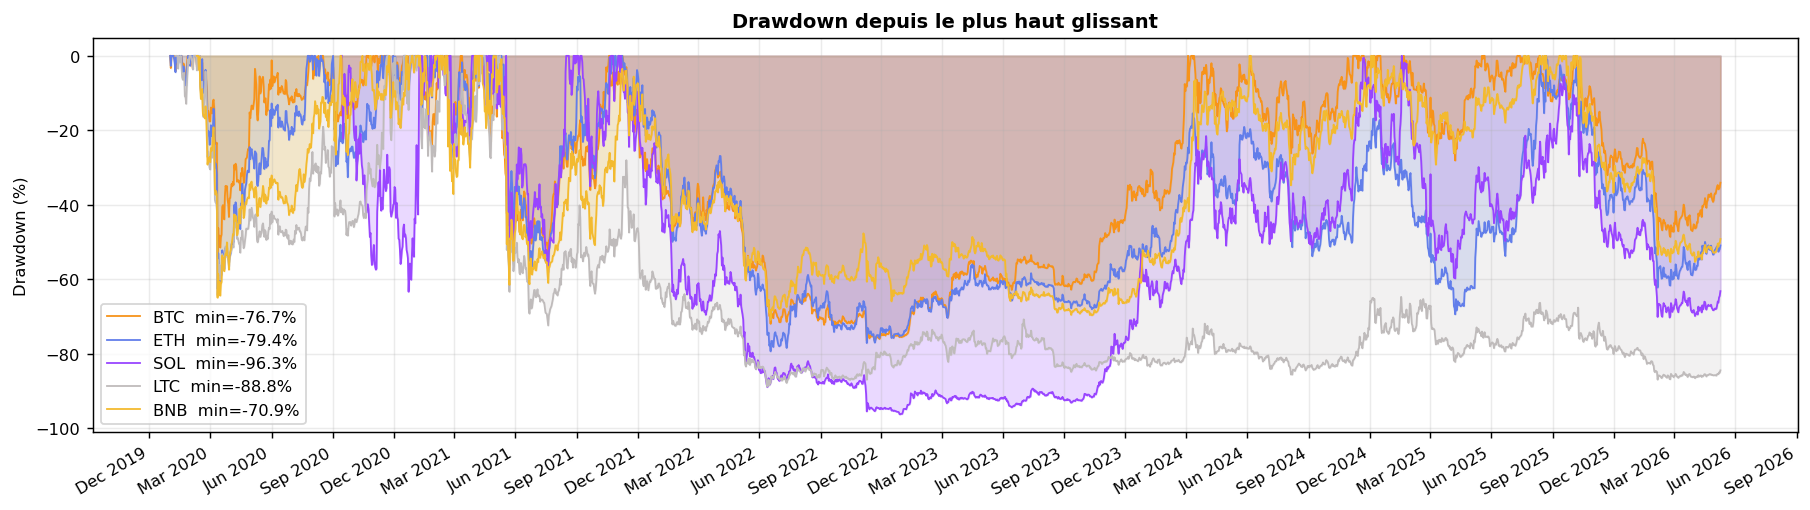

In [4]:
fig, ax = plt.subplots(figsize=(14, 4))

for sym, df in data.items():
    roll_max = df['close'].cummax()
    dd = (df['close'] - roll_max) / roll_max * 100
    ax.fill_between(dd.index, dd, 0, alpha=0.2, color=COLORS[sym])
    ax.plot(dd.index, dd, lw=1.0, color=COLORS[sym],
            label=f"{sym.replace('USDT', '')}  min={dd.min():.1f}%")

ax.set_ylabel('Drawdown (%)')
ax.set_title('Drawdown depuis le plus haut glissant', fontweight='bold')
ax.legend()
ax.grid(alpha=0.25)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 4 · Statistiques résumées

In [5]:
rows = []
for sym, df in data.items():
    ret     = df['ret'].dropna()
    roll_max = df['close'].cummax()
    dd      = (df['close'] - roll_max) / roll_max
    perf    = df['close'].iloc[-1] / df['close'].iloc[0] - 1
    ann_ret = ret.mean() * 365
    ann_vol = ret.std()  * np.sqrt(365)
    rows.append({
        'Asset':          sym.replace('USDT', ''),
        'Perf totale':    f'{perf*100:+.1f}%',
        'Ret ann. (log)': f'{ann_ret*100:+.1f}%',
        'Vol ann.':       f'{ann_vol*100:.1f}%',
        'Sharpe':         f'{ann_ret/ann_vol:.2f}',
        'Max DD':         f'{dd.min()*100:.1f}%',
        'Vol moy/j (Md$)':f'{df["quote_vol"].mean()/1e9:.2f}',
    })

pd.DataFrame(rows).set_index('Asset')

,Perf totale,Ret ann. (log),Vol ann.,Sharpe,Max DD,Vol moy/j (Md$)
Asset,,,,,,
BTC,+1041.7%,+38.3%,62.6%,0.61,-76.7%,13.24
ETH,+1714.6%,+45.6%,83.7%,0.54,-79.4%,7.79
SOL,+2852.1%,+59.9%,116.6%,0.51,-96.3%,1.99
LTC,+35.0%,+4.7%,89.9%,0.05,-88.8%,0.32
BNB,+2536.6%,+52.4%,84.0%,0.62,-70.9%,0.62
